In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import statsmodels.api as sm

#three different datasets from last 3 years

df = pd.read_csv(r'C:\Users\tilen\season-2324.csv')
df1 = pd.read_csv(r'C:\Users\tilen\season-2425.csv')
df2 = pd.read_csv(r'C:\Users\tilen\season-2526.csv')

#we merge them to one

df_bund = pd.concat([df, df1, df2], axis=0)

#we drop the columns we don't need

df_bund = df_bund.drop(columns= ['Referee', 'HY', 'AY', 'HF', 'AF', 'HR', 'AR'])
df_bund

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC
0,2023-08-18,Werder Bremen,Bayern Munich,0,4,A,0.0,1.0,A,6.0,25.0,1.0,10.0,0.0,6.0
1,2023-08-19,Augsburg,M'gladbach,4,4,D,3.0,3.0,D,20.0,9.0,8.0,6.0,8.0,7.0
2,2023-08-19,Hoffenheim,Freiburg,1,2,A,0.0,2.0,A,24.0,17.0,5.0,8.0,4.0,2.0
3,2023-08-19,Leverkusen,RB Leipzig,3,2,H,2.0,1.0,H,11.0,13.0,7.0,6.0,4.0,5.0
4,2023-08-19,Stuttgart,Bochum,5,0,H,2.0,0.0,H,19.0,4.0,9.0,1.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2026-05-16,Leverkusen,Hamburg,1,1,D,0.0,0.0,D,26.0,19.0,9.0,6.0,8.0,3.0
302,2026-05-16,M'gladbach,Hoffenheim,4,0,H,2.0,0.0,H,9.0,11.0,6.0,3.0,2.0,9.0
303,2026-05-16,St Pauli,Wolfsburg,1,3,A,0.0,1.0,A,11.0,19.0,2.0,10.0,8.0,9.0
304,2026-05-16,Union Berlin,Augsburg,4,0,H,2.0,0.0,H,17.0,11.0,9.0,1.0,4.0,9.0


In [2]:
#we compute the total number of goals conceded by teams at home and away

home_goals = df_bund.groupby('HomeTeam')['FTAG'].sum()
away_goals = df_bund.groupby('AwayTeam')['FTHG'].sum()


stats1 = pd.DataFrame()


stats1['Home_Goals_Con'] = home_goals
stats1['Away_Goals_Con'] = away_goals

stats1['Total_Goals_Con'] = stats1['Home_Goals_Con'] + stats1['Away_Goals_Con'] 

stats1 = stats1.reset_index().rename(columns={'HomeTeam': 'Team'})
stats1

,Team,Home_Goals_Con,Away_Goals_Con,Total_Goals_Con
0,Augsburg,74,98,172
1,Bayern Munich,47,66,113
2,Bochum,62,79,141
3,Darmstadt,44,42,86
4,Dortmund,57,71,128
5,Ein Frankfurt,70,91,161
6,FC Koln,58,65,123
7,Freiburg,78,90,168
8,Hamburg,22,32,54
9,Heidenheim,96,95,191


In [3]:
#we have to find the number of games played by each team

df_bund['HomeTeam'] = df_bund['HomeTeam'].astype(str).str.strip()
df_bund['AwayTeam'] = df_bund['AwayTeam'].astype(str).str.strip()

home_counts = df_bund['HomeTeam'].value_counts().reset_index()
home_counts.columns = ['Team', 'HomeGames']

away_counts = df_bund['AwayTeam'].value_counts().reset_index()
away_counts.columns = ['Team', 'AwayGames']


Total_Games_stats = pd.merge(home_counts, away_counts, on='Team', how='outer')

Total_Games_stats['Total_Games'] = Total_Games_stats['HomeGames'] + Total_Games_stats['AwayGames']
Total_Games_stats

,Team,HomeGames,AwayGames,Total_Games
0,Augsburg,51,51,102
1,Bayern Munich,51,51,102
2,Bochum,34,34,68
3,Darmstadt,17,17,34
4,Dortmund,51,51,102
5,Ein Frankfurt,51,51,102
6,FC Koln,34,34,68
7,Freiburg,51,51,102
8,Hamburg,17,17,34
9,Heidenheim,51,51,102


In [4]:
#here we merge the list with the mean number of goals conceded by a team 
#with the list of total games played by the teams

teams_goals_con = pd.merge(stats1, Total_Games_stats, on='Team', how='outer') 

teams_goals_con

,Team,Home_Goals_Con,Away_Goals_Con,Total_Goals_Con,HomeGames,AwayGames,Total_Games
0,Augsburg,74,98,172,51,51,102
1,Bayern Munich,47,66,113,51,51,102
2,Bochum,62,79,141,34,34,68
3,Darmstadt,44,42,86,17,17,34
4,Dortmund,57,71,128,51,51,102
5,Ein Frankfurt,70,91,161,51,51,102
6,FC Koln,58,65,123,34,34,68
7,Freiburg,78,90,168,51,51,102
8,Hamburg,22,32,54,17,17,34
9,Heidenheim,96,95,191,51,51,102


In [5]:
#we will find now the total number of half time goals each team conceded

stats3 = pd.DataFrame()

df_bund['HTHG'] = pd.to_numeric(df_bund['HTHG'], errors='coerce')
df_bund['HTAG'] = pd.to_numeric(df_bund['HTAG'], errors='coerce')

#at this part of the code we compute the total number of goals
#conceded by a team by the half time, when this team played at home and away

home = df_bund.groupby('HomeTeam')['HTAG'].sum().reset_index()
home.columns = ['Team', 'HalfTimeHomeGoalsCon']

away = df_bund.groupby('AwayTeam')['HTHG'].sum().reset_index()
away.columns = ['Team', 'HalfTimeAwayGoalsCon']

stats3 = pd.merge(home, away, on='Team', how='outer')

#we add the total half time goals conceded by a team at home and away
#to find the total number of goals conceded by the half time

stats3['TotalHTGoalsCon'] = stats3['HalfTimeHomeGoalsCon'] + stats3['HalfTimeAwayGoalsCon']


Total_Goals_Stats = pd.merge(stats1, stats3, on='Team', how='outer')


teams_goals_con = pd.merge(Total_Goals_Stats, Total_Games_stats, on='Team', how='outer')

#here we compute the mean number of goals conceded by a team 
#and the mean number of goals conceded by a team by the half time

teams_goals_con['mean_goals_con'] = teams_goals_con['Total_Goals_Con'] / teams_goals_con['Total_Games'] 
teams_goals_con['mean_htgoals_con'] = teams_goals_con['TotalHTGoalsCon'] / teams_goals_con['Total_Games'] 

teams_goals_con

,Team,Home_Goals_Con,Away_Goals_Con,Total_Goals_Con,HalfTimeHomeGoalsCon,HalfTimeAwayGoalsCon,TotalHTGoalsCon,HomeGames,AwayGames,Total_Games,mean_goals_con,mean_htgoals_con
0,Augsburg,74,98,172,38.0,55.0,93.0,51,51,102,1.686275,0.911765
1,Bayern Munich,47,66,113,20.0,32.0,52.0,51,51,102,1.107843,0.509804
2,Bochum,62,79,141,26.0,35.0,61.0,34,34,68,2.073529,0.897059
3,Darmstadt,44,42,86,23.0,16.0,39.0,17,17,34,2.529412,1.147059
4,Dortmund,57,71,128,27.0,34.0,61.0,51,51,102,1.254902,0.598039
5,Ein Frankfurt,70,91,161,35.0,38.0,73.0,51,51,102,1.578431,0.715686
6,FC Koln,58,65,123,22.0,30.0,52.0,34,34,68,1.808824,0.764706
7,Freiburg,78,90,168,40.0,31.0,71.0,51,51,102,1.647059,0.696078
8,Hamburg,22,32,54,12.0,13.0,25.0,17,17,34,1.588235,0.735294
9,Heidenheim,96,95,191,44.0,52.0,96.0,51,51,102,1.872549,0.941176


In [8]:
#at this part of the code we start the computation of the winning percentage
#in order to do that, we first check who won the game. If home team won the game
#we put at the home_count variable the value 1 and if away team won we put 1 at the away_count
#if the game ended as a draw, we put in both variables 0.5

df_bund['home_count'] = np.where(df_bund['FTR'] == 'H',1, np.where(df_bund['FTR'] == 'D',0.5,0))
df_bund['away_count'] = np.where(df_bund['FTR'] == 'A',1, np.where(df_bund['FTR'] == 'D',0.5,0))
df_bund

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC,home_count,away_count
0,2023-08-18,Werder Bremen,Bayern Munich,0,4,A,0.0,1.0,A,6.0,25.0,1.0,10.0,0.0,6.0,0.0,1.0
1,2023-08-19,Augsburg,M'gladbach,4,4,D,3.0,3.0,D,20.0,9.0,8.0,6.0,8.0,7.0,0.5,0.5
2,2023-08-19,Hoffenheim,Freiburg,1,2,A,0.0,2.0,A,24.0,17.0,5.0,8.0,4.0,2.0,0.0,1.0
3,2023-08-19,Leverkusen,RB Leipzig,3,2,H,2.0,1.0,H,11.0,13.0,7.0,6.0,4.0,5.0,1.0,0.0
4,2023-08-19,Stuttgart,Bochum,5,0,H,2.0,0.0,H,19.0,4.0,9.0,1.0,7.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2026-05-16,Leverkusen,Hamburg,1,1,D,0.0,0.0,D,26.0,19.0,9.0,6.0,8.0,3.0,0.5,0.5
302,2026-05-16,M'gladbach,Hoffenheim,4,0,H,2.0,0.0,H,9.0,11.0,6.0,3.0,2.0,9.0,1.0,0.0
303,2026-05-16,St Pauli,Wolfsburg,1,3,A,0.0,1.0,A,11.0,19.0,2.0,10.0,8.0,9.0,0.0,1.0
304,2026-05-16,Union Berlin,Augsburg,4,0,H,2.0,0.0,H,17.0,11.0,9.0,1.0,4.0,9.0,1.0,0.0


In [9]:
team_wins = pd.DataFrame()

#first we compute the sum of the 'points' of home team and away team 

home_points = df_bund.groupby('HomeTeam')['home_count'].sum().reset_index()
home_points.columns = ['Team', 'HomePoints']

away_points = df_bund.groupby('AwayTeam')['away_count'].sum().reset_index()
away_points.columns = ['Team', 'AwayPoints']

team_wins = pd.merge(home_points, away_points, on='Team', how='outer')

#here we add the points at home and away

team_wins['TotalPoints'] = team_wins['HomePoints'] + team_wins['AwayPoints']

#finally we divide the total points each team won, with the total number of games each team played
#and we find the winning percentage of each team

team_wins['win_pct'] = team_wins['TotalPoints'] / Total_Games_stats['Total_Games']

team_wins

,Team,HomePoints,AwayPoints,TotalPoints,win_pct
0,Augsburg,27.0,19.0,46.0,0.450980
1,Bayern Munich,44.5,39.0,83.5,0.818627
2,Bochum,14.0,8.5,22.5,0.330882
3,Darmstadt,2.5,4.5,7.0,0.205882
4,Dortmund,38.0,30.0,68.0,0.666667
5,Ein Frankfurt,32.0,24.0,56.0,0.549020
6,FC Koln,13.0,10.5,23.5,0.345588
7,Freiburg,30.5,21.5,52.0,0.509804
8,Hamburg,9.0,5.5,14.5,0.426471
9,Heidenheim,20.0,16.5,36.5,0.357843


In [8]:
#we compute the total goals scored from teams at home and away

home_goals = df_bund.groupby('HomeTeam')['FTHG'].sum()
away_goals = df_bund.groupby('AwayTeam')['FTAG'].sum()


stats2 = pd.DataFrame()


stats2['Home_Goals'] = home_goals
stats2['Away_Goals'] = away_goals

#we compute the total goals of the season

stats2['Total_Goals'] = stats2['Home_Goals'].fillna(0) + stats2['Away_Goals'].fillna(0)  #fillna(0) puts 0 if we have any NaN value

stats2 = stats2.reset_index().rename(columns={'HomeTeam': 'Team'})
stats2

,Team,Home_Goals,Away_Goals,Total_Goals
0,Augsburg,69,61,130
1,Bayern Munich,174,141,315
2,Bochum,42,33,75
3,Darmstadt,15,15,30
4,Dortmund,121,88,209
5,Ein Frankfurt,99,81,180
6,FC Koln,45,32,77
7,Freiburg,93,52,145
8,Hamburg,25,15,40
9,Heidenheim,66,62,128


In [9]:
#here we will compute the pythogorean winning percentage
#the formula is : pyth_pct = TotalGoalsScored * 2 / (TotalGoalsScored * 2 + TotalGoalsConceded * 2) 

team_wins['pyth_pct'] = stats2['Total_Goals'] * 2 / (stats2['Total_Goals'] * 2 + teams_goals_con['Total_Goals_Con'] * 2)
team_wins

,Team,HomePoints,AwayPoints,TotalPoints,win_pct,pyth_pct
0,Augsburg,27.0,19.0,46.0,0.450980,0.430464
1,Bayern Munich,44.5,39.0,83.5,0.818627,0.735981
2,Bochum,14.0,8.5,22.5,0.330882,0.347222
3,Darmstadt,2.5,4.5,7.0,0.205882,0.258621
4,Dortmund,38.0,30.0,68.0,0.666667,0.620178
5,Ein Frankfurt,32.0,24.0,56.0,0.549020,0.527859
6,FC Koln,13.0,10.5,23.5,0.345588,0.385000
7,Freiburg,30.5,21.5,52.0,0.509804,0.463259
8,Hamburg,9.0,5.5,14.5,0.426471,0.425532
9,Heidenheim,20.0,16.5,36.5,0.357843,0.401254


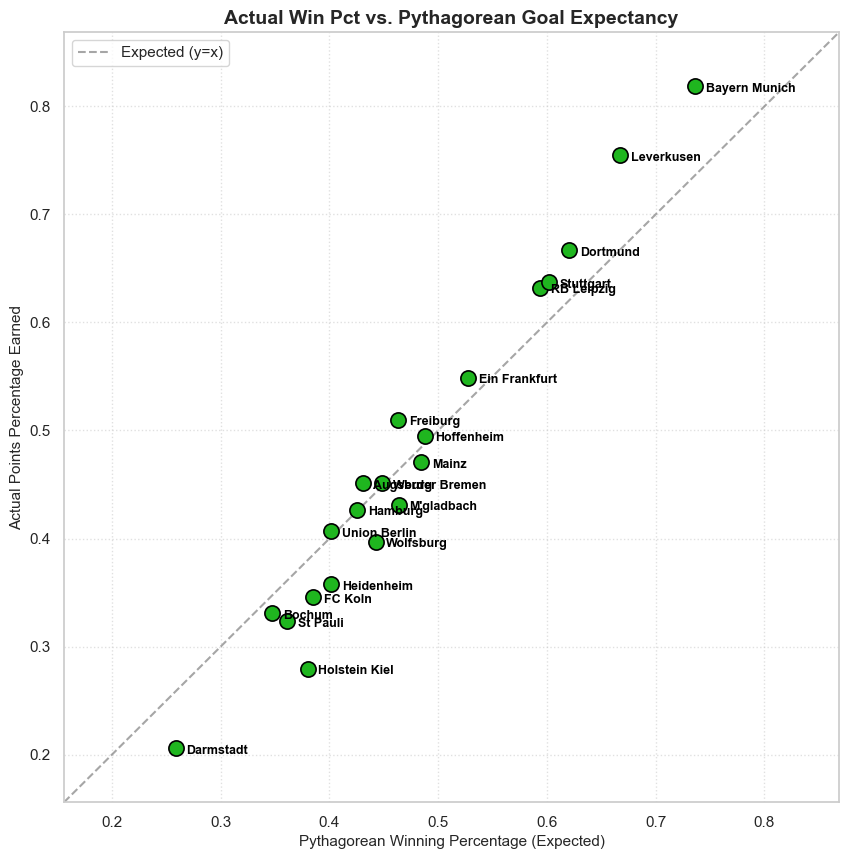

In [27]:
#here we create the plot of winning pct and pythagorean winning pct

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 10))

x_vals = team_wins["pyth_pct"]
y_vals = team_wins["win_pct"]
teams = team_wins["Team"]

min_val = min(x_vals.min(), y_vals.min()) - 0.05
max_val = max(x_vals.max(), y_vals.max()) + 0.05
line_coords = [min_val, max_val]

plt.plot(
    line_coords,
    line_coords,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Expected (y=x)",)

plt.scatter(x_vals,
    y_vals,
    s=120,  
    color="#1FB61F",  
    edgecolor="black",  
    linewidth=1.2,
    zorder=3,  
)


for i in range(len(team_wins)):
    plt.text(
        x=x_vals.iloc[i] + 0.01, 
        y=y_vals.iloc[i] - 0.005, 
        s=teams.iloc[i],  
        fontdict=dict(color="black", size=9, weight="bold"),
    )

plt.title('Actual Win Pct vs. Pythagorean Goal Expectancy', fontsize=14, weight="bold")
plt.xlabel('Pythagorean Winning Percentage (Expected)', fontsize=11)
plt.ylabel('Actual Points Percentage Earned', fontsize=11)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, linestyle=":", alpha=0.6, zorder=1)
plt.legend(loc="upper left")

plt.show()